### Final Project : Eigen-Value Decomposition (EVD)
[Obsidian - Final Project](https://publish.obsidian.md/marco/Course/DSP+In+VLSI/Project-Note/Final+Project)

#### Envrionment Setup & Data Loading

In [ ]:
# Import Library
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# RMSE line plot palette (IEEE-style, colorblind-friendly)
C_RMSE_LAM = "#1F4E79"      # deep navy
C_RMSE_VEC = "#008571"      # muted teal
C_RMSE_THRESH = "#C0392B"   # academic red

# Increase the resolution of the output images
%config InlineBackend.figure_format = 'retina'

# Load Data
data = sio.loadmat("Final11Pattern.mat") # Dictionary Type
keys = [k for k in data if not k.startswith("__")] # Get the key, ignoring the hidden variables
print(keys)
Matrix = data.get("Matrix")   # (3, 3, 11)
print(Matrix.shape)

['Matrix']
(3, 3, 11)


#### Create Bit-True Model for EVD by Iterative QR

In [41]:
# Reference Eigen-Value Decomposition
def reference_evd(A):
    return np.linalg.eigh(A)

# Quantization
def quantize(z, b):
    return np.floor(z * 2**b) / 2**b

# CORDIC Scaling Factor
def cordic_scaling_factor(n_stages):
    K = 1.0
    for i in range(n_stages):
        K *= np.sqrt(1.0 + 2.0 ** (-2 * i))
    return K

# Configuration Quantization Setting Class
class EVDConfig:

    def __init__(
        self,
        b=16,           # fractional bits for quantize
        n_stages=16,    # CORDIC micro-rotation stages
        mu=0.0,         # fixed shift
        max_iter=8,     # QR iterations
    ):
        self.b = b
        self.n_stages = n_stages
        self.mu = mu
        self.max_iter = max_iter

    # Define the quantization function
    def q(self, z):
        return quantize(z, self.b)

# CORDIC Vectoring Mode
def cordic_vectoring(x, y, cfg):
    q = cfg.q
    w_xy = cfg.b
    phase_adjust = 0.0

    if x < 0:
        phase_adjust = q(np.pi) if y >= 0 else q(-np.pi)
        x, y = -x, -y

    xi = int(np.floor(x * 2**w_xy))
    yi = int(np.floor(y * 2**w_xy))
    theta = 0.0

    for i in range(cfg.n_stages):
        mu = -1 if yi > 0 else 1
        elem_angle = q(np.arctan(2.0 ** -i))
        dX = yi >> i
        dY = xi >> i
        xi = xi - mu * dX
        yi = yi + mu * dY
        theta = q(theta - mu * elem_angle)

    k = cordic_scaling_factor(cfg.n_stages)
    x_out = q(xi / (2**w_xy) / k)
    y_out = q(yi / (2**w_xy) / k)
    theta_out = q(theta + phase_adjust)
    return x_out, y_out, theta_out

# CORDIC Rotation Mode
def cordic_rotation(x, y, theta, cfg):
    q = cfg.q
    w_xy = cfg.b
    z = q(theta)

    if z > q(np.pi / 2):
        x, y = -x, -y
        z = q(z - q(np.pi))
    elif z < -q(np.pi / 2):
        x, y = -x, -y
        z = q(z + q(np.pi))

    xi = int(np.floor(x * 2**w_xy))
    yi = int(np.floor(y * 2**w_xy))

    for i in range(cfg.n_stages):
        elem_angle = q(np.arctan(2.0 ** -i))
        dX = yi >> i
        dY = xi >> i
        if z >= 0:
            xi = xi + dX
            yi = yi - dY
            z = q(z - elem_angle)
        else:
            xi = xi - dX
            yi = yi + dY
            z = q(z + elem_angle)

    k = cordic_scaling_factor(cfg.n_stages)
    x_out = q(xi / (2**w_xy) / k)
    y_out = q(yi / (2**w_xy) / k)
    return x_out, y_out

# Apply 1 Givens Rotation to R
def apply_givens_rows(M, p, q, col, cfg):
    M = np.array(M, dtype=float, copy=True) # make M copy
    # extract the two rows to be rotated and make copies -> quantization
    rp = cfg.q(M[p, :].copy())
    rq = cfg.q(M[q, :].copy())
    # vectoring: zero pivot and obtain theta
    rp[col], rq[col], theta = cordic_vectoring(rp[col], rq[col], cfg)
    # rotation: apply same theta to remaining columns
    for m in range(col + 1, M.shape[1]):
        rp[m], rq[m] = cordic_rotation(rp[m], rq[m], theta, cfg)
    # update the matrix
    M[p, :] = rp
    M[q, :] = rq
    return M, theta


# Givens Rotation Order Setting [row1, row2, col]
GIVENS_PAIRS = [(0, 1, 0), (0, 2, 0), (1, 2, 1)]

# QR Decomposition, getting complete R
def qrd_phase2(T, cfg):
    R = cfg.q(np.array(T, dtype=float, copy=True))
    thetas = []
    for p, q, col in GIVENS_PAIRS:
        R, theta = apply_givens_rows(R, p, q, col, cfg)
        thetas.append(theta)
    return cfg.q(R), thetas

# Givens Rotation using thetas from QR Decomposition
def qrd_rotation_pass(M, thetas, cfg, columns=False):
    M = np.array(M, dtype=float, copy=True)
    for (p, q, _col), theta in zip(GIVENS_PAIRS, thetas):
        if columns:
            cp = cfg.q(M[:, p].copy())
            cq = cfg.q(M[:, q].copy())
            for i in range(M.shape[0]):
                cp[i], cq[i] = cordic_rotation(cp[i], cq[i], theta, cfg)
            M[:, p] = cp
            M[:, q] = cq
        else:
            rp = cfg.q(M[p, :].copy())
            rq = cfg.q(M[q, :].copy())
            for m in range(M.shape[1]):
                rp[m], rq[m] = cordic_rotation(rp[m], rq[m], theta, cfg)
            M[p, :] = rp
            M[q, :] = rq
    return cfg.q(M)


# Matrix Transpose
def matrix_transpose(M, cfg):
    return cfg.q(np.array(M.T, dtype=float, copy=True))


# Eigen-Value Decomposition by Iterative QR Algorithm
def iterative_qr_evd(A, cfg):
    n = A.shape[0]
    T = cfg.q(np.array(A, dtype=float)) # initial T = q(A)
    U = cfg.q(np.eye(n)) # Initialize: U = q(I)
    iters = 0
    I = np.eye(n)

    for _ in range(cfg.max_iter):
        iters += 1
        T_shifted = cfg.q(T - cfg.mu * I) # Hessenberg Reduction & Shift
        R, thetas = qrd_phase2(T_shifted, cfg) # QR Decomposition, Get R
        RT = matrix_transpose(R, cfg) # Transpose R
        T = cfg.q(qrd_rotation_pass(RT, thetas, cfg) + cfg.mu * I) # T = (RQ)^T
        U = qrd_rotation_pass(U, thetas, cfg, columns=True)  # U = UQ

    lam = np.diag(T) # Get Eigenvalues
    return lam, U, T, iters


# Use Reference to Align Eigenvector Order
def align_eigenpairs(lam_ref, V_ref, lam_hat, V_hat):
    idx = np.argsort(lam_hat)
    lam_hat = lam_hat[idx]
    V_hat = V_hat[:, idx]
    for i in range(len(lam_ref)):
        if np.dot(V_ref[:, i], V_hat[:, i]) < 0:
            V_hat[:, i] *= -1
    return lam_hat, V_hat


# RMSE of Eigenvalues
def rmse_eigenvalues(lam_ref, lam_hat):
    return float(np.sqrt(np.mean((lam_ref - lam_hat) ** 2)))


# RMSE of Eigenvectors
def rmse_eigenvectors(V_ref, V_hat):
    sq = sum(
        np.linalg.norm(V_ref[:, i] - V_hat[:, i]) ** 2
        for i in range(V_ref.shape[1])
    )
    return float(np.sqrt(sq / 9))


def evaluate_evd(A, cfg):
    lam_ref, V_ref = reference_evd(A)
    lam_hat, V_hat, _, n_iter = iterative_qr_evd(A, cfg)
    lam_hat, V_hat = align_eigenpairs(lam_ref, V_ref, lam_hat, V_hat)
    return {
        "rmse_lam": rmse_eigenvalues(lam_ref, lam_hat),
        "rmse_vec": rmse_eigenvectors(V_ref, V_hat),
        "n_iter": n_iter,
        "lam_ref": lam_ref,
        "lam_hat": lam_hat,
    }


def evaluate_all_patterns(Matrix, cfg):
    n_sets = Matrix.shape[2]
    rmse_lam = np.zeros(n_sets)
    rmse_vec = np.zeros(n_sets)
    for s in range(n_sets):
        r = evaluate_evd(Matrix[:, :, s], cfg)
        rmse_lam[s] = r["rmse_lam"]
        rmse_vec[s] = r["rmse_vec"]
    return rmse_lam, rmse_vec


#### RMSE verus wordlength & CORDIC stages

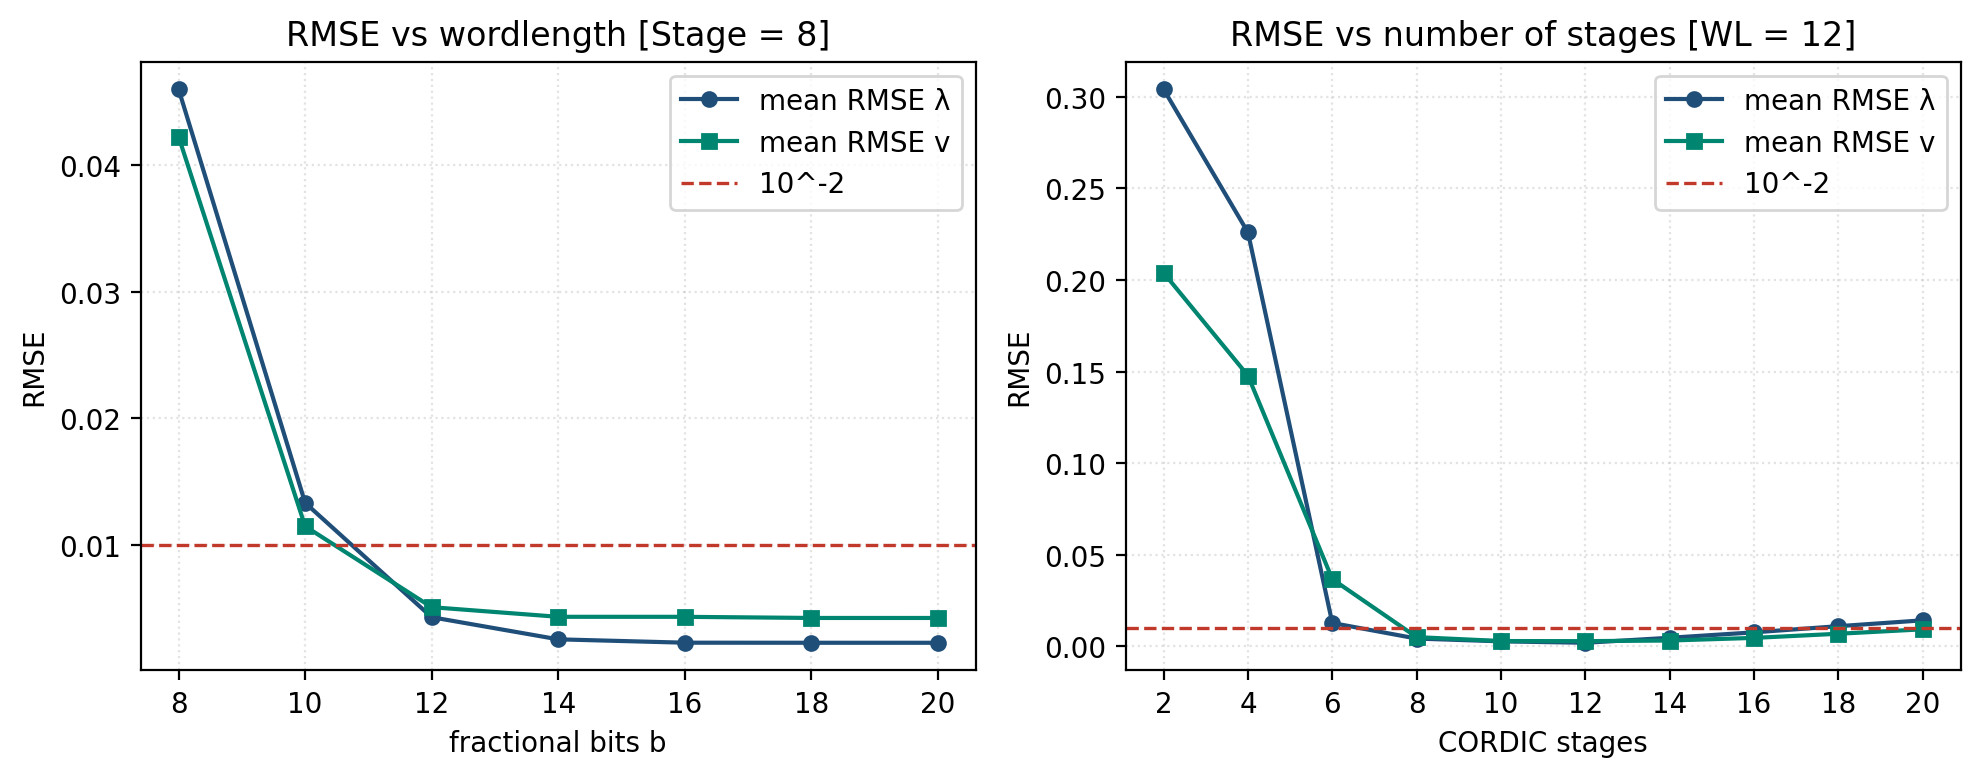

In [49]:
## RMSE verus wordlength & CORDIC stages
def sweep_wordlength(Matrix, b_list, n_stages):
    mean_lam, mean_vec, max_lam, max_vec = [], [], [], []
    for b in b_list:
        cfg = EVDConfig(b, n_stages, 0.0, 8)
        rl, rv = evaluate_all_patterns(Matrix, cfg)
        mean_lam.append(rl.mean())
        mean_vec.append(rv.mean())
        max_lam.append(rl.max())
        max_vec.append(rv.max())
    return np.array(mean_lam), np.array(mean_vec), np.array(max_lam), np.array(max_vec)

# RMSE verus CORDIC stages
def sweep_stages(Matrix, stage_list, b):
    mean_lam, mean_vec, max_lam, max_vec = [], [], [], []
    for n in stage_list:
        cfg = EVDConfig(b, n, 0.0, 8)
        rl, rv = evaluate_all_patterns(Matrix, cfg)
        mean_lam.append(rl.mean())
        mean_vec.append(rv.mean())
        max_lam.append(rl.max())
        max_vec.append(rv.max())
    return np.array(mean_lam), np.array(mean_vec), np.array(max_lam), np.array(max_vec)


# Example sweeps (adjust ranges as needed)
B_LIST = [8, 10, 12, 14, 16, 18, 20]
STAGE_LIST = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

# Draw the Figure
ml, mv, xl, xv = sweep_wordlength(Matrix, B_LIST, n_stages=8)
sl, sv, _, _ = sweep_stages(Matrix, STAGE_LIST, b=12)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(B_LIST, ml, "o-", color=C_RMSE_LAM, label="mean RMSE λ", linewidth=1.5, markersize=5)
axes[0].plot(B_LIST, mv, "s-", color=C_RMSE_VEC, label="mean RMSE v", linewidth=1.5, markersize=5)
axes[0].axhline(1e-2, color=C_RMSE_THRESH, ls="--", linewidth=1.2, label="10^-2")
axes[0].set_xlabel("fractional bits b")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE vs wordlength [Stage = 8]")
axes[0].set_xticks(B_LIST)
axes[0].legend()
axes[0].grid(True, alpha=0.35, linestyle=":")

axes[1].plot(STAGE_LIST, sl, "o-", color=C_RMSE_LAM, label="mean RMSE λ", linewidth=1.5, markersize=5)
axes[1].plot(STAGE_LIST, sv, "s-", color=C_RMSE_VEC, label="mean RMSE v", linewidth=1.5, markersize=5)
axes[1].axhline(1e-2, color=C_RMSE_THRESH, ls="--", linewidth=1.2, label="10^-2")
axes[1].set_xlabel("CORDIC stages")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE vs number of stages [WL = 12]")
axes[1].set_xticks(STAGE_LIST)
axes[1].legend()
axes[1].grid(True, alpha=0.35, linestyle=":")
plt.tight_layout()
plt.show()

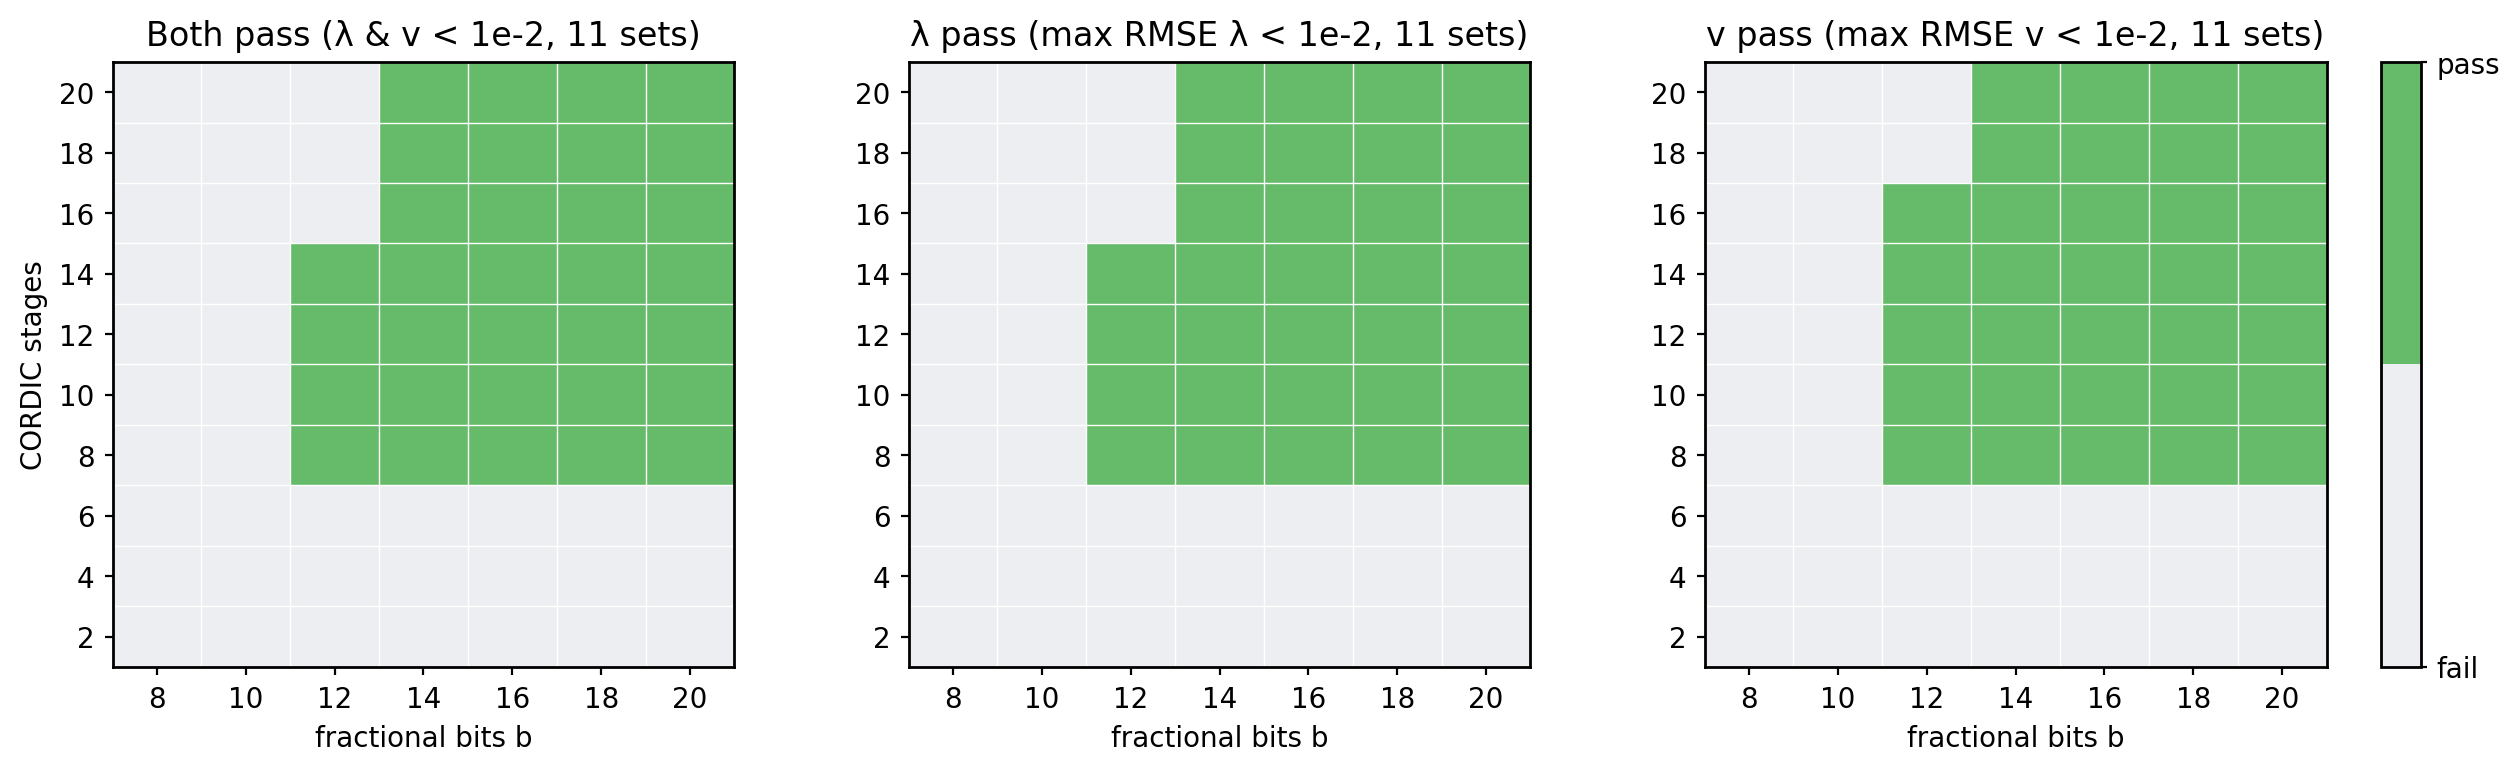

In [43]:
# 2D sweep for min-parameter search
RMSE_THRESH = 1e-2

def sweep_grid(Matrix, b_list, stage_list, max_iter=8):
    nb, ns = len(b_list), len(stage_list)
    max_lam = np.zeros((ns, nb))
    max_vec = np.zeros((ns, nb))
    pass_all = np.zeros((ns, nb), dtype=bool)

    for i, n in enumerate(stage_list):
        for j, b in enumerate(b_list):
            cfg = EVDConfig(b, n, 0.0, max_iter)
            rl, rv = evaluate_all_patterns(Matrix, cfg)
            max_lam[i, j] = rl.max()
            max_vec[i, j] = rv.max()
            pass_all[i, j] = (rl < RMSE_THRESH).all() and (rv < RMSE_THRESH).all()
    return max_lam, max_vec, pass_all


B_GRID = [8, 10, 12, 14, 16, 18, 20]
STAGE_GRID = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

max_lam_2d, max_vec_2d, pass_2d = sweep_grid(Matrix, B_GRID, STAGE_GRID, max_iter=8)
pass_lam_2d = max_lam_2d < RMSE_THRESH
pass_vec_2d = max_vec_2d < RMSE_THRESH


CMAP_PASS = ListedColormap(["#ECEEF1", "#66BB6A"])

def plot_pass_map(ax, pass_map, title, show_ylabel=True):
    im = ax.imshow(
        pass_map.astype(float),
        origin="lower",
        aspect="auto",
        cmap=CMAP_PASS,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_xticks(np.arange(-0.5, len(B_GRID), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(STAGE_GRID), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.5, linestyle="-")
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(range(len(B_GRID)), B_GRID)
    ax.set_yticks(range(len(STAGE_GRID)), STAGE_GRID)
    ax.set_xlabel("fractional bits b")
    if show_ylabel:
        ax.set_ylabel("CORDIC stages")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=True)
    ax.set_title(title)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("black")
    ax.tick_params(width=0.8, length=3, colors="black")
    return im


fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

ims = [
    plot_pass_map(axes[0], pass_2d, "Both pass (λ & v < 1e-2, 11 sets)"),
    plot_pass_map(axes[1], pass_lam_2d, "λ pass (max RMSE λ < 1e-2, 11 sets)", show_ylabel=False),
    plot_pass_map(axes[2], pass_vec_2d, "v pass (max RMSE v < 1e-2, 11 sets)", show_ylabel=False),
]

fig.subplots_adjust(left=0.08, right=0.90, bottom=0.16, top=0.88, wspace=0.28)
cax = fig.add_axes([0.92, 0.16, 0.015, 0.72])
cbar = fig.colorbar(ims[0], cax=cax, ticks=[0, 1])
cbar.ax.set_yticklabels(["fail", "pass"])
cbar.outline.set_linewidth(1.0)
cbar.outline.set_edgecolor("black")
cbar.ax.tick_params(width=0.8, length=2, colors="black")

plt.show()

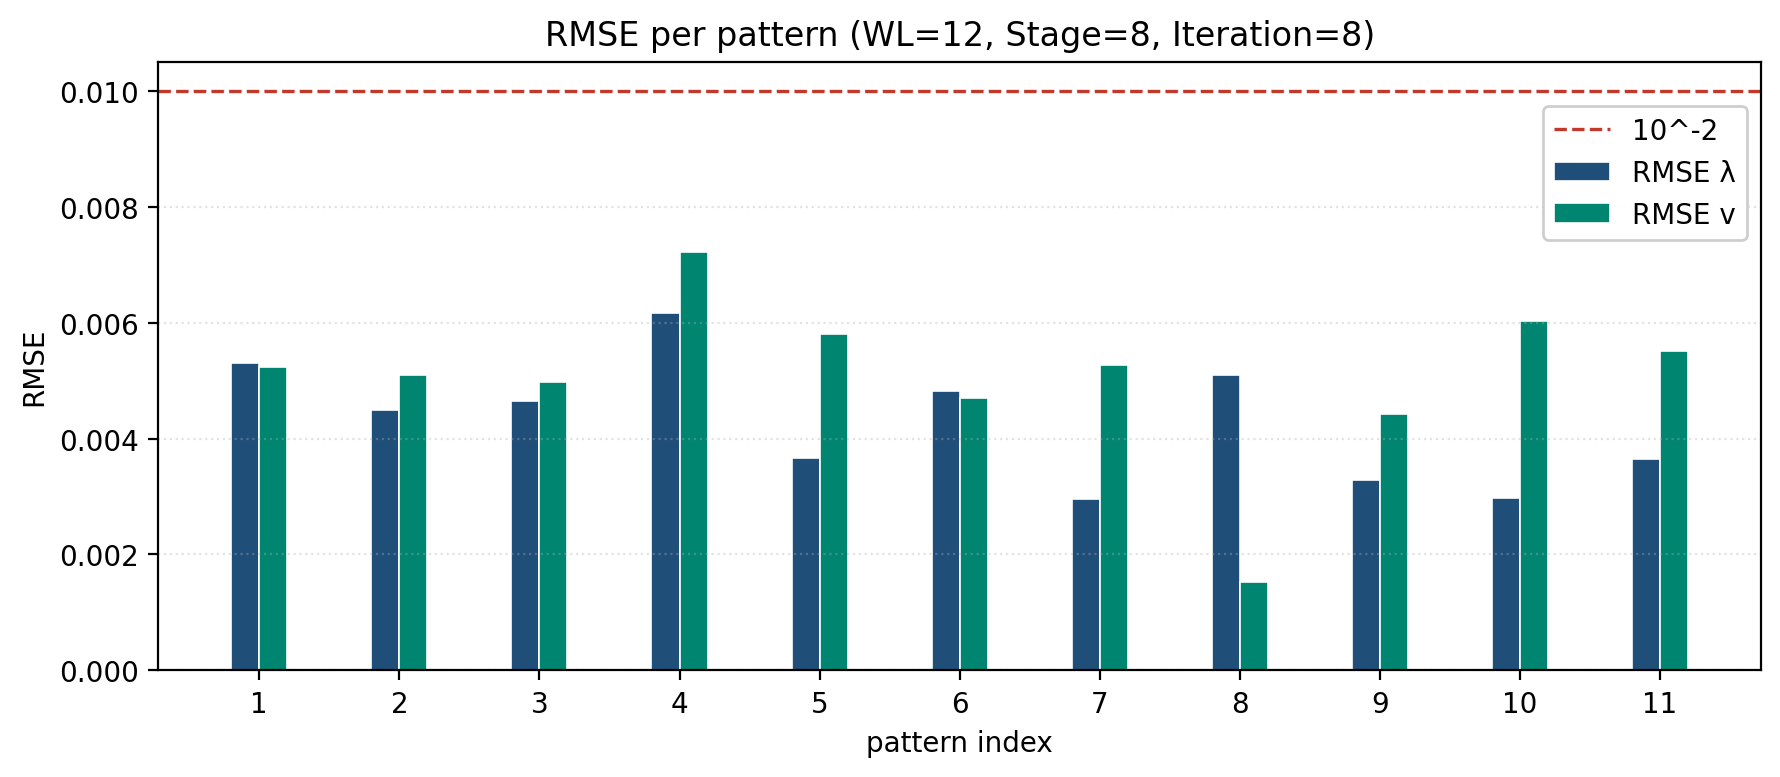

In [48]:
# Evaluate 11 patterns (Requirement 1: RMSE λ and v < 1e-2)
B = 12
N_STAGES = 8
MAX_ITER = 8
RMSE_THRESH = 1e-2

cfg = EVDConfig(B, N_STAGES, 0.0, MAX_ITER)
rmse_lam, rmse_vec = evaluate_all_patterns(Matrix, cfg)

idx = np.arange(1, Matrix.shape[2] + 1)
bar_w = 0.2
x = np.arange(Matrix.shape[2])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - bar_w / 2, rmse_lam, bar_w, color=C_RMSE_LAM, label="RMSE λ", edgecolor="white", linewidth=0.6)
ax.bar(x + bar_w / 2, rmse_vec, bar_w, color=C_RMSE_VEC, label="RMSE v", edgecolor="white", linewidth=0.6)
ax.axhline(RMSE_THRESH, color=C_RMSE_THRESH, ls="--", linewidth=1.2, label="10^-2")
ax.set_xlabel("pattern index")
ax.set_ylabel("RMSE")
ax.set_title(f"RMSE per pattern (WL={B}, Stage={N_STAGES}, Iteration={MAX_ITER})")
ax.set_xticks(x, idx)
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.95), framealpha=0.95)
ax.grid(True, axis="y", alpha=0.35, linestyle=":")
plt.tight_layout()
plt.show()

#### Determine the Total WordLength of Hardware